In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sn
import matplotlib.pyplot as plt

In [29]:
df=pd.read_csv('/content/mtsamples.csv')
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [30]:
df=df[['transcription', 'medical_specialty']]
df=df.dropna()

In [31]:
df['medical_specialty'].value_counts()

,count
medical_specialty,
Surgery,1088
Consult - History and Phy.,516
Cardiovascular / Pulmonary,371
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,224
Neurology,223
SOAP / Chart / Progress Notes,166


In [32]:
top5=df['medical_specialty'].value_counts().head(5).index
df=df[df['medical_specialty'].isin(top5)]

In [33]:
le=LabelEncoder()
df['specialty_encoded']=le.fit_transform(df['medical_specialty'])

In [34]:
X=df['transcription']
y=df['specialty_encoded']

In [35]:
cv=CountVectorizer(stop_words='english')
X=cv.fit_transform(X)

In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
model=MultinomialNB()
model.fit(X_train,y_train)
predictions=model.predict(X_test)

In [38]:
cm=confusion_matrix(y_test, predictions)

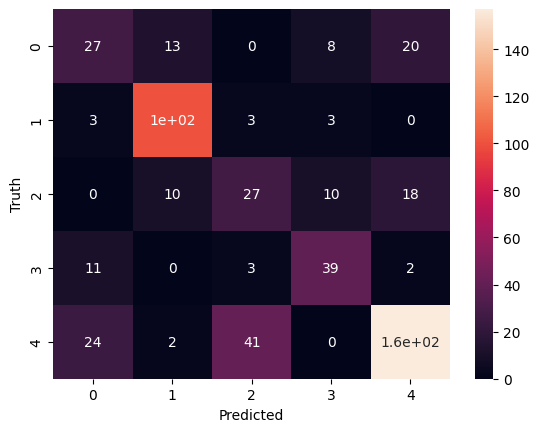

In [39]:
sn.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

In [40]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.42      0.40      0.41        68
           1       0.80      0.92      0.85       109
           2       0.36      0.42      0.39        65
           3       0.65      0.71      0.68        55
           4       0.80      0.70      0.75       224

    accuracy                           0.67       521
   macro avg       0.61      0.63      0.61       521
weighted avg       0.68      0.67      0.67       521

